# PDF Parsing with MinerU

## Raw Data Loading and Explore

In [1]:
from huggingface_hub import snapshot_download
from pathlib import Path
import json
import base64
from collections import Counter
from IPython.display import display, Image, HTML


# Save data in PixelRAG/data/ relative to this notebook
local_data_dir = Path("data")
local_data_dir.mkdir(parents=True, exist_ok=True)

repo_dir = snapshot_download(
    repo_id="vectara/open_ragbench",
    repo_type="dataset",
    local_dir=str(local_data_dir),
    ignore_patterns=["*.gitattributes"]
)
print(f"Downloaded to: {repo_dir}")

/Users/hanhanwu/Documents/Github/Yokan/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
base = Path("data/pdf/arxiv")

queries = json.loads((base / "queries.json").read_text())
qrels = json.loads((base / "qrels.json").read_text())
pdf_urls = json.loads((base / "pdf_urls.json").read_text())

print(f"Total queries: {len(queries)}")
print(f"Total qrels:   {len(qrels)}")
print(f"Total PDFs:    {len(pdf_urls)}")

source_counts = Counter(v["source"] for v in queries.values())
print("\nQuery sources:", source_counts)

Total queries: 3045
Total qrels:   3045
Total PDFs:    1000

Query sources: Counter({'text': 1914, 'text-image': 763, 'text-table-image': 220, 'text-table': 148})


#### Get an Example Paper with both Image and Table

In [3]:
corpus_dir = Path("data/pdf/arxiv/corpus")
paper_files = sorted(corpus_dir.glob("*.json"))

min_images = 1
papers_with_both = []

for path in paper_files:
    doc = json.loads(path.read_text())
    img_count = sum(len(s.get("images", {})) for s in doc["sections"])
    table_count = sum(len(s.get("tables", {})) for s in doc["sections"])
    if img_count >= min_images and table_count > 0:
        papers_with_both.append((img_count, table_count, doc))

papers_with_both.sort(key=lambda x: (x[0], x[1]), reverse=True)

# Change this index to explore different papers
paper_index = 12
target_paper = papers_with_both[paper_index][2]

print(f"Index: {paper_index}")
print(f"Paper: {target_paper['title']}")
print(f"Images: {papers_with_both[paper_index][0]}")
print(f"Tables: {papers_with_both[paper_index][1]}")
print(f"Sections: {len(target_paper['sections'])}")

Index: 12
Paper: Unsolvable Problem Detection: Robust Understanding Evaluation for Large
  Multimodal Models
Images: 31
Tables: 18
Sections: 70


In [4]:
# Find first section with a table and render it as HTML
for section in target_paper["sections"]:
    if section.get("tables"):
        table_md = next(iter(section["tables"].values()))
        rows = [r.strip() for r in table_md.strip().splitlines() if r.strip() and "---" not in r]
        html = "<table border='1' style='border-collapse:collapse;font-size:12px'>"
        for i, row in enumerate(rows):
            tag = "th" if i == 0 else "td"
            cells = [c.strip() for c in row.strip("|").split("|")]
            html += "<tr>" + "".join(f"<{tag} style='padding:4px 8px'>{c}</{tag}>" for c in cells) + "</tr>"
        html += "</table>"
        display(HTML(f"<h4>Table from: {target_paper['title'][:60]}...</h4>" + html))
        break

,AAD,,,,IASD,,,,IVQD,,,
:--:,:--:,:--:,:--:,:--:,:--:,:--:,:--:,:--:,:--:,:--:,:--:,:--:
,Orig,Base,Opt,Inst,Orig,Base,Opt,Inst,Orig,Base,Opt,Inst
Open-source LMMs,,,,,,,,,,,,
LLaVA1.5-13b,74.4,0.7,38.8,37.1,70.9,5.7,46.0,52.0,68.8,0.0,39.3,31.7
LLaVA-NeXT-13B,76.7,17.8,18.2,38.3,73.2,27.0,29.6,55.9,71.3,33.1,37.9,54.2
LLaVA-NeXT-34B,84.3,50.5,29.9,55.1,80.2,48.9,22.6,61.8,80.9,55.3,50.6,72.5
LLaVA-OV-0.5B,67.0,22.2,18.2,0.1,64.4,17.8,11.5,3.8,59.6,9.6,7.9,3.1
LLaVA-OV-7B,86.0,4.5,29.4,25.9,82.5,5.5,37.0,27.1,84.8,2.5,50.6,47.8
Phi-3-Vision,80.4,0.1,27.4,38.8,77.0,0.1,46.5,49.0,79.5,0.0,56.2,61.0
Phi-3.5-Vision,80.2,1.8,22.2,27.7,77.1,0.3,23.9,33.2,77.2,0.3,52.5,55.9


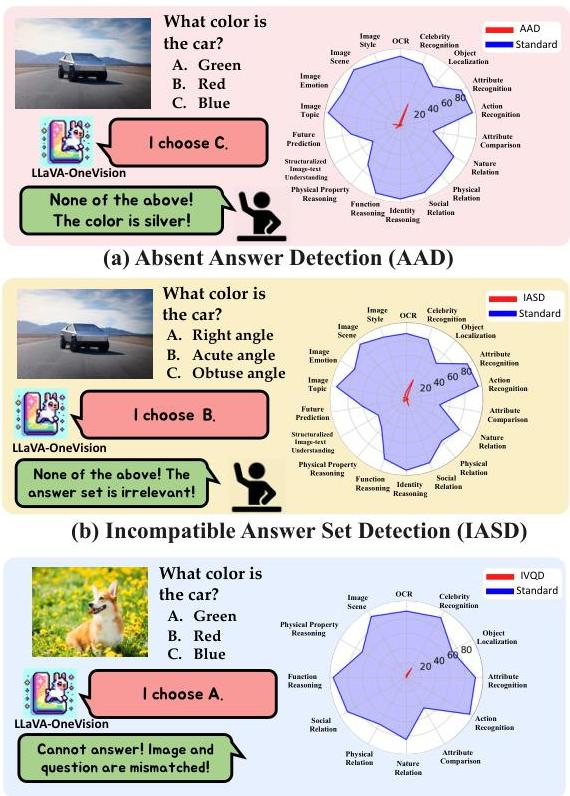

In [5]:
# Find first section with an image and display it
for section in target_paper["sections"]:
    if section.get("images"):
        img_b64 = next(iter(section["images"].values()))
        img_bytes = base64.b64decode(img_b64.split(",", 1)[1])
        display(Image(data=img_bytes, width=780))
        break

In [6]:
# Find queries linked to the selected paper
paper_id = target_paper.get("id")

if paper_id is None:
    raise KeyError(f"Could not find paper ID. Available keys: {list(target_paper.keys())}")

linked_query_ids = [
    qid for qid, rel in qrels.items()
    if rel["doc_id"] == paper_id
]

print(f"Queries linked to this paper: {len(linked_query_ids)}\n")
for qid in linked_query_ids[:5]:
    q = queries[qid]
    print(f"[{q['source']:20s}] [{q['type']:11s}]  {q['query'][:90]}")

Queries linked to this paper: 10

[text                ] [extractive ]  What does MM-UPD Bench stand for?
[text                ] [extractive ]  Is detailed justification required when refining problems during the curation process?
[text                ] [extractive ]  Is there a strong correlation between OC-Dual accuracy and Dual accuracy?
[text                ] [extractive ]  Does self-reflection allow models to evaluate their own answers?
[text                ] [extractive ]  What activity involves using ropes and harnesses on a cliff face?


## MinerU Data Parsing

* Install MinerU
  * `pip install uv`
  * `uv pip install -U "mineru[all]"`

### MinerU vs Docling
<b>Tables Extraction</b>
* MinerU
  * Uses dedicated table-recognition models (in PDF-Extract-Kit) that predict cell bounding boxes, row/column relationships, and hierarchical header structures.
  * It tries to reconstruct the table’s logical grid, including multi-row or multi-column headers, so it can emit something closer to the original table structure.

* Docling
  * Treats tables as document-layout objects and converts them to a flat Markdown/HTML grid.
  * Its pipeline is optimized for producing clean, readable document output rather than perfect cell-level reconstruction.
  * Merging cells is its way of handling spans, multi-row headers, or irregular grids — it simplifies the table into a rectangular shape even if that loses some hierarchical information.

* Docling’s table model is more conservative. If it is uncertain about cell boundaries or sees a complex span, it prefers to merge adjacent cells rather than risk producing a broken grid.
* MinerU’s table model is more aggressive about keeping the original grid structure, which sometimes means it preserves hierarchy but can also produce errors when the table is irregular.


<b>Images Extraction</b>
* MinerU
  * Uses a layout detector that crops every visually distinct region it classifies as an image.
  * If a page has a large figure made of multiple sub-panels, or a figure surrounded by captions and small annotations, MinerU may output each sub-region as a separate image.
  * It does not try to merge nearby image regions into one semantic figure.

* Docling
  * Builds a document object model and groups visual regions into semantic Picture nodes.
  * It tends to merge adjacent image-like regions that belong to the same figure into one picture.
  * It also filters out very small or decorative regions, so sub-panels or captions may be absorbed into one larger picture or dropped entirely.

In [9]:
# ---- Pre-download MinerU models to avoid HF Hub transient failures ----
# MinerU's pipeline backend needs the PDF-Extract-Kit-1.0 models. Downloading
# them explicitly via huggingface_hub before invoking mineru avoids the
# "LocalEntryNotFoundError" that can happen when mineru tries to fetch them.
from huggingface_hub import snapshot_download

model_cache_path = snapshot_download(
    repo_id="opendatalab/PDF-Extract-Kit-1.0",
    repo_type="model",
    allow_patterns=["models/MFR/unimernet_hf_small_2503/*"],
)
print(f"MinerU MFR model cached at: {model_cache_path}")


Fetching 7 files: 100%|██████████| 7/7 [00:00<00:00, 80218.93it/s]

MinerU MFR model cached at: /Users/hanhanwu/.cache/huggingface/hub/models--opendatalab--PDF-Extract-Kit-1.0/snapshots/ed6b654c018d742e65a17671e379c5e6ecc87ec9


In [12]:
# ---- Download the selected PDF ----
import subprocess
import requests
from pathlib import Path
from IPython.display import display, Markdown

# Anchor all paths to the notebook's directory so outputs are predictable
# regardless of where the Jupyter kernel was started.
try:
    from IPython import get_ipython
    ip = get_ipython()
    if ip is not None and hasattr(ip, "kernel"):
        # Running inside a Jupyter kernel; ask the kernel for the notebook path.
        nb_path = Path(ip.kernel.shell.user_ns.get("__vsc_ipynb_file__", ""))
        if nb_path.exists():
            nb_dir = nb_path.parent
        else:
            nb_dir = Path.cwd()
    else:
        nb_dir = Path(__file__).parent
except Exception:
    nb_dir = Path.cwd()

paper_id = target_paper.get("id")
pdf_url = pdf_urls.get(paper_id)
print(f"Paper ID: {paper_id}")
print(f"PDF URL:  {pdf_url}")

pdf_path = nb_dir / "data" / "pdf" / "arxiv" / f"{paper_id}.pdf"
pdf_path.parent.mkdir(parents=True, exist_ok=True)
if not pdf_path.exists():
    r = requests.get(pdf_url, timeout=60)
    r.raise_for_status()
    pdf_path.write_bytes(r.content)
    print(f"Downloaded PDF ({len(r.content):,} bytes) to {pdf_path}")
else:
    print(f"Using cached PDF at {pdf_path}")

# ---- Run MinerU via CLI ----
# backend="pipeline" is the CPU/MPS-friendly option — good fit for an M-series Mac
# without needing a CUDA-only vlm-engine backend.
mineru_output_dir = nb_dir / "data" / "pdf" / "arxiv" / "mineru_output"
mineru_output_dir.mkdir(parents=True, exist_ok=True)

cmd = [
    "mineru",
    "-p", str(pdf_path),
    "-o", str(mineru_output_dir),
    "-b", "pipeline",
    "-l", "en",          # document language, improves OCR accuracy
    "-f", "true",        # enable formula parsing (LaTeX)
    "-t", "true",        # enable table parsing
]
print(f"\nRunning: {' '.join(cmd)}\n")
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout[-2000:])  # tail of logs
if result.returncode != 0:
    print("STDERR:", result.stderr[-2000:])

# MinerU 3.4.4 writes pipeline-backend results to: <output_dir>/<pdf_stem>/auto/
parse_dir = mineru_output_dir / pdf_path.stem / "auto"
md_path = parse_dir / f"{pdf_path.stem}.md"
content_list_path = parse_dir / f"{pdf_path.stem}_content_list.json"
images_dir = parse_dir / "images"

print(f"\nParse dir: {parse_dir}")
print(f"Parse dir exists: {parse_dir.exists()}")
print(f"Parse dir contents: {list(parse_dir.iterdir()) if parse_dir.exists() else 'NOT FOUND'}")


Paper ID: 2403.20331v2
PDF URL:  https://arxiv.org/pdf/2403.20331v2
Using cached PDF at /Users/hanhanwu/Documents/Github/Yokan/experiments_multimodal/PixelRAG/data/pdf/arxiv/2403.20331v2.pdf

Running: mineru -p /Users/hanhanwu/Documents/Github/Yokan/experiments_multimodal/PixelRAG/data/pdf/arxiv/2403.20331v2.pdf -o /Users/hanhanwu/Documents/Github/Yokan/experiments_multimodal/PixelRAG/data/pdf/arxiv/mineru_output -b pipeline -l en -f true -t true

Start MinerU FastAPI Service: http://127.0.0.1:51140
API documentation: http://127.0.0.1:51140/docs


Parse dir: /Users/hanhanwu/Documents/Github/Yokan/experiments_multimodal/PixelRAG/data/pdf/arxiv/mineru_output/2403.20331v2/auto
Parse dir exists: True
Parse dir contents: [PosixPath('/Users/hanhanwu/Documents/Github/Yokan/experiments_multimodal/PixelRAG/data/pdf/arxiv/mineru_output/2403.20331v2/auto/2403.20331v2_middle.json'), PosixPath('/Users/hanhanwu/Documents/Github/Yokan/experiments_multimodal/PixelRAG/data/pdf/arxiv/mineru_output/2403.

In [13]:
# ---- Show extracted Markdown ----
if md_path.exists():
    mineru_markdown = md_path.read_text(encoding="utf-8")
    print(f"MinerU Markdown length: {len(mineru_markdown):,} chars")
    display(Markdown("## MinerU Parsed Markdown (first 3,000 chars)"))
    display(Markdown(mineru_markdown[:3000] + "\n\n..."))
else:
    print(f"Markdown not found at {md_path}")


MinerU Markdown length: 128,868 chars


## MinerU Parsed Markdown (first 3,000 chars)

# Unsolvable Problem Detection: Robust Understanding Evaluation for Large Multimodal Models

Atsuyuki Miyai<sup>1</sup> Jingkang Yang<sup>2</sup> Jingyang Zhang<sup>3</sup> Yifei Ming<sup>4</sup> Qing Yu<sup>1,5</sup> Go Irie<sup>6</sup> Yixuan Li<sup>4</sup> Hai Li<sup>3</sup> Ziwei Liu<sup>2</sup> Kiyoharu Aizawa<sup>1</sup> <sup>1</sup>The University of Tokyo <sup>2</sup>S-Lab, Nanyang Technological University <sup>3</sup>Duke University <sup>4</sup>University of Wisconsin-Madison <sup>5</sup>LY Corporation <sup>6</sup>Tokyo University of Science

https://github.com/AtsuMiyai/UPD

## Abstract

This paper introduces a novel task to evaluate the robust understanding capability of Large Multimodal Models (LMMs), termed Unsolvable Problem Detection (UPD). Multiplechoice question answering (MCQA) is widely used to assess the understanding capability of LMMs, but it does not guarantee that LMMs truly comprehend the answer. UPD assesses the LMM’s ability to withhold answers when encountering unsolvable problems of MCQA, verifying whether the model truly understands the answer. UPD encompasses three problems: Absent Answer Detection (AAD), Incompatible Answer Set Detection (IASD), and Incompatible Visual Question Detection (IVQD), covering unsolvable cases like answer-lacking or incompatible choices and image-question mismatches. For the evaluation, we introduce the MM-UPD Bench, a benchmark for assessing performance across various ability dimensions. Our experiments reveal that even most LMMs, which demonstrate adequate performance on existing benchmarks, struggle significantly with MM-UPD, underscoring a novel aspect of trustworthiness that current benchmarks have overlooked. A detailed analysis shows that LMMs have different bottlenecks and chain-of-thought and self-reflection im proved performance for LMMs with the bot tleneck in their LLM capability. We hope our insights will enhance the broader understanding and development of more reliable LMMs.

## 1 Introduction

In recent years, following the revolutionary development of Large Language Models (LLMs) (Chen et al., 2024a; Chiang et al., 2023; Touvron et al., 2023; Wei et al., 2023), Large Multimodal Models (LMMs) (Liu et al., 2024c; Wang et al., 2023c; Hurst et al., 2024) have also demonstrated profound capabilities in various applications and significantly enhance the performance in image reasoning tasks (Antol et al., 2015; Liu et al., 2024b,e; Yue et al., 2024a).

![](images/f974a47f88df69e2ec1cb1a3c353029b9081220f2a52a41fb698148e4b5fe901.jpg)  
(a) Absent Answer Detection (AAD)

![](images/bb6e79644ac527e3cc0232aba6ebf2a653fc581af4a145321c4a11a082edfd6d.jpg)  
(b) Incompatible Answer Set Detection (IASD)

![](images/c908a811ce9eca15b45381c51b72255e4dbf193861e4f6be5b3ca77fd1d07714.jpg)  
(c) Incompatible Visual Question Detection (IVQD) Figure 1: The Unsolvable Problem Detection (UPD) Challenges. Current Large Multimodal Models (LMMs) like LLaVA-OneVision show adequate performance (blue) on

...

In [17]:
# ---- Show structured tables from MinerU content list ----
import json

if content_list_path.exists():
    content_list = json.loads(content_list_path.read_text(encoding="utf-8"))
    table_items = [item for item in content_list if item.get("type") == "table"]
    print(f"Number of tables found by MinerU: {len(table_items)}\n")

    for idx, item in enumerate(table_items[:3], start=1):
        display(Markdown(f"### Table {idx}"))
        # MinerU may store table text/markdown under different keys depending on version
        table_text = item.get("text") or item.get("markdown") or item.get("html") or str(item)
        display(Markdown(table_text))
else:
    print(f"Content list not found at {content_list_path}")


Number of tables found by MinerU: 21



### Table 1

{'type': 'table', 'img_path': 'images/15d0dfa246b724983f8644ffc290201fb0abbb4ae110147ee36789dc078fc76d.jpg', 'table_caption': ['Table 1: Comparison results of the overall Dual accuracy for the base setting, additional-option setting, and additional-instruction setting. The “Orig” (Original Standard) value is the upper bound of Dual accuracy. The results show that the difference between each Dual accuracy and the Original Standard is clear and most open-source LMMs have significantly low scores.'], 'table_footnote': [], 'table_body': '<table><tr><td></td><td colspan="4">AAD</td><td colspan="4">IASD</td><td colspan="4">IVQD</td></tr><tr><td></td><td>Orig</td><td>Base</td><td>Opt</td><td>Inst</td><td>Orig</td><td>Base</td><td> Opt</td><td>Inst</td><td>Orig</td><td>Base</td><td>Opt</td><td>Inst</td></tr><tr><td colspan="9">Open-source LMMs</td><td></td><td></td><td></td><td></td></tr><tr><td>LLaVA1.5-13b</td><td>74.4</td><td>0.7</td><td>38.8</td><td>37.1</td><td>70.8</td><td>5.7</td><td>46.0</td><td>52.0</td><td>68.8</td><td>0.0</td><td>39.3</td><td>31.7</td></tr><tr><td>LLaVA-NeXT-13B</td><td>76.7</td><td>17.8</td><td>18.2</td><td>38.3</td><td>73.2</td><td>27.0</td><td>29.6</td><td>55.9</td><td>71.3</td><td>33.1</td><td>37.9</td><td>54.2</td></tr><tr><td>LLaVA-NeXT-34B</td><td>84.3</td><td>50.5</td><td>29.9</td><td>55.1</td><td>80.2</td><td>48.9</td><td>22.6</td><td>61.8</td><td>80.9</td><td>55.3</td><td>50.6</td><td>72.5</td></tr><tr><td>LLaVA-OV-0.5B</td><td>67.0</td><td>22.2</td><td>18.2</td><td>0.1</td><td>64.4</td><td>17.8</td><td>11.5</td><td>3.8</td><td>59.6</td><td>9.6</td><td>7.9</td><td>3.1</td></tr><tr><td>LLaVA-OV-7B</td><td>86.0</td><td>4.5</td><td>29.4</td><td>25.9</td><td>82.5</td><td>5.5</td><td>37.0</td><td>27.1</td><td>84.8</td><td>2.5</td><td>50.6</td><td>47.8</td></tr><tr><td>Phi-3-Vision</td><td>80.4</td><td>0.1</td><td>27.4</td><td>38.8</td><td>77.0</td><td>0.1</td><td>46.5</td><td>49.0</td><td>79.5</td><td>0.0</td><td>56.2</td><td>61.0</td></tr><tr><td>Phi-3.5-Vision</td><td>80.2</td><td>1.8</td><td>22.2</td><td>27.7</td><td>77.1</td><td>0.3</td><td>23.9</td><td>33.2</td><td>77.2</td><td>0.3</td><td>52.5</td><td>55.9</td></tr><tr><td>CogVLM-17B</td><td>71.5</td><td>0.5</td><td>39.3</td><td>3.8</td><td>67.7</td><td>0.5</td><td>18.3</td><td>4.4</td><td>62.9</td><td>0.0</td><td>19.4</td><td>9.0</td></tr><tr><td>CogVLM2-19B Idefics2-8B</td><td>84.0</td><td>0.0</td><td>46.1</td><td>44.5</td><td>80.8</td><td>0.1</td><td>51.6</td><td>58.2</td><td>85.4</td><td>0.0</td><td>42.7</td><td>42.7</td></tr><tr><td>idefics3-8B</td><td>76.1</td><td>1.0</td><td>30.1</td><td>27.3</td><td>72.5</td><td>1.1</td><td>39.6</td><td>45.2</td><td>73.0</td><td>1.4</td><td>49.2</td><td>45.8</td></tr><tr><td>InternVL2-2B</td><td>81.0 78.2</td><td>0.1 6.8</td><td>33.3 30.6</td><td>29.1</td><td>77.8</td><td>0.3</td><td>50.5</td><td>52.2</td><td>79.8</td><td>3.7</td><td>53.4</td><td>41.3</td></tr><tr><td>InternVL2-8B</td><td>87.7</td><td>28.5</td><td>56.0</td><td>17.4 34.0</td><td>74.2 83.9</td><td>14.6</td><td>50.6</td><td>17.8</td><td>76.4</td><td>15.4</td><td>19.9</td><td>14.3 59.6</td></tr><tr><td>InternVL2-40B</td><td>91.1</td><td>43.5</td><td>55.9</td><td>67.9</td><td>87.9</td><td>30.1 45.0</td><td>66.3 59.8</td><td>56.5 75.7</td><td>86.5</td><td>28.4</td><td>58.7 56.2</td><td>80.6</td></tr><tr><td>Xgen-MM</td><td>83.2</td><td>0.7</td><td>38.3</td><td></td><td>80.0</td><td></td><td></td><td></td><td>90.7</td><td>42.7</td><td></td><td></td></tr><tr><td>Qwen2-VL-7B</td><td>84.4</td><td>11.5</td><td>38.4</td><td>31.6 48.3</td><td>81.0</td><td>0.1</td><td>52.1</td><td>42.5</td><td>80.9</td><td>0.0</td><td>58.1</td><td>35.1</td></tr><tr><td>Qwen2.5-VL-7B</td><td>88.7</td><td>32.2</td><td>49.0</td><td>58.5</td><td>84.9</td><td>19.7 46.1</td><td>49.9 70.0</td><td>64.0</td><td>80.1</td><td>37.1</td><td>63.5</td><td>69.1</td></tr><tr><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td><td>70.4</td><td>84.3</td><td>71.1</td><td>74.7</td><td>79.5</td></tr><tr><td colspan="10">Closed-source LMMs</td><td></td><td>57.3</td><td></td></tr><tr><td>GeminiPro</td><td>72.7</td><td>24.5</td><td>40.1</td><td>42.9</td><td>70.9</td><td>28.1</td><td>48.5</td><td>552.1</td><td>69.1</td><td>37.6</td><td></td><td>60.4</td></tr><tr><td>Gemini1.5Pro</td><td>79.4</td><td>47.8</td><td>49.0</td><td>52.3</td><td>75.7</td><td>57.7</td><td>65.8</td><td>60.5</td><td>73.9</td><td>69.1</td><td>71.9</td><td>68.3</td></tr><tr><td>GPT4V</td><td>80.0</td><td>52.4</td><td>50.5</td><td>56.5</td><td>75.8</td><td>60.2</td><td>65.6</td><td>60.8</td><td>75.3</td><td>62.4</td><td>61.2</td><td>58.4</td></tr><tr><td>GPT4o-mini</td><td>78.0</td><td>33.5</td><td>48.9</td><td>45.1</td><td>75.6</td><td>46.5</td><td>63.0</td><td>56.9</td><td>72.8</td><td>48.3</td><td>58.4</td><td>47.5</td></tr><tr><td>GPT40</td><td>83.2</td><td>45.6</td><td>57.8</td><td>59.3</td><td>80.5</td><td>56.1</td><td>68.9</td><td>68.0</td><td>76.4</td><td>65.2</td><td>69.4</td><td>66.0</td></tr></table>', 'bbox': [178, 71, 810, 354], 'page_idx': 5}

### Table 2

{'type': 'table', 'img_path': 'images/ac06e08e64da40477d35bef1748de5b60fe539f677ad92e950042e9a193ea7ab.jpg', 'table_caption': ['Table 2: Correlation coefficients for Original Standard vs. Dual/UPD accuracy.'], 'table_footnote': [], 'table_body': '<table><tr><td colspan="2"></td><td>Dual</td><td>UPD</td></tr><tr><td rowspan="3">AAD</td><td>Base</td><td>25.9</td><td>22.3</td></tr><tr><td>Opt</td><td>49.5</td><td>37.4</td></tr><tr><td>Inst</td><td>64.9</td><td>22.5</td></tr><tr><td rowspan="3">IASD</td><td>Base</td><td>27.0</td><td>19.6</td></tr><tr><td>Opt</td><td>56.5</td><td>42.3</td></tr><tr><td>Inst</td><td>65.4</td><td>29.9</td></tr><tr><td rowspan="3">IVQD</td><td>Base</td><td>14.6</td><td>6.5</td></tr><tr><td>Opt</td><td>56.7</td><td>35.6</td></tr><tr><td>Inst</td><td>62.6</td><td>39.1</td></tr></table>', 'bbox': [643, 429, 850, 576], 'page_idx': 5}

### Table 3

{'type': 'table', 'img_path': 'images/2464e013eed6567dfa92a78e3c1d3150d20d278b0c264a29c402bde3d3501f4f.jpg', 'table_caption': ['Table 3: Overall Dual accuracy with chain of thought prompting and self-reflection. The values in () represent Standard accuracy and UPD accuracy, respectively.'], 'table_footnote': [], 'table_body': '<table><tr><td></td><td></td><td>LLaVA NeXT13B</td><td>LLaVA-OV-7B</td><td>InternVL2-8B</td><td>GPT-40</td></tr><tr><td>AAD</td><td>Base CoT Self-reflection</td><td>17.8 (72.6/23.2) 42.8 (60.0/60.5) 37.8 (66.2/50.0)</td><td>4.5 (85.4/5.1) 37.9 (77.1/42.8) 27.6 (84.6/29.1)</td><td>28.5 (82.7/30.2) 29.0 (83.7/29.6) 38.7 (81.5/41.2)</td><td>45.6 (80.2/52.3) 47.7 (77.9/56.0) 55.2 (69.8/75.1)</td></tr><tr><td>IASD</td><td>Base CoT Self-reflection</td><td>27.0 (68.9/40.8) 43.9 (56.4/70.8) 36.7 (62.6/55.8)</td><td>5.5 (81.8/5.7) 36.7 (73.7/45.7) 35.4 (81.1/45.2)</td><td>30.1 (78.3/35.0) 29.4 (79.5/32.5) 34.0 (77.4/41.0)</td><td>56.1 (77.9/70.0) 48.4 (74.5/64.2) 57.9 (61.8/83.6)</td></tr><tr><td>IVQD</td><td>Base CoT Self-reflection</td><td>33.1 (67.4/44.9) 47.5 (59.0/75.3) 39.0 (59.8/61.5)</td><td>2.5 (85.4/3.1) 14.9 (75.3/18.0) 31.7 (85.4/34.6)</td><td>28.4 (82.3/35.1) 14.9 (83.1/17.1) 30.3 (81.2/37.9)</td><td>65.2 (73.6/90.2) 57.2 (70.5/83.4) 57.9 (61.8/96.1)</td></tr></table>', 'bbox': [176, 71, 811, 209], 'page_idx': 7}

Number of true images found by MinerU: 19



### Image 1: f974a47f88df69e2ec1cb1a3c353029b9081220f2a52a41fb698148e4b5fe901.jpg (size: (565, 234))

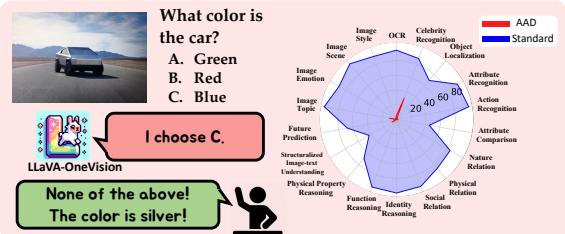

### Image 2: bb6e79644ac527e3cc0232aba6ebf2a653fc581af4a145321c4a11a082edfd6d.jpg (size: (567, 237))

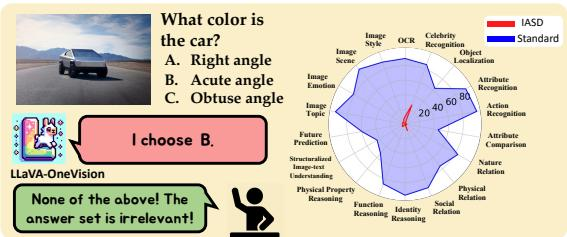

### Image 3: c908a811ce9eca15b45381c51b72255e4dbf193861e4f6be5b3ca77fd1d07714.jpg (size: (564, 231))

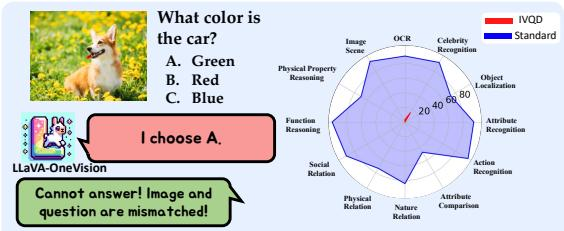

### Image 4: 8e55325c0797874808fbf88e4726d2818c53ea647ec576f6895753b97614baa6.jpg (size: (780, 332))

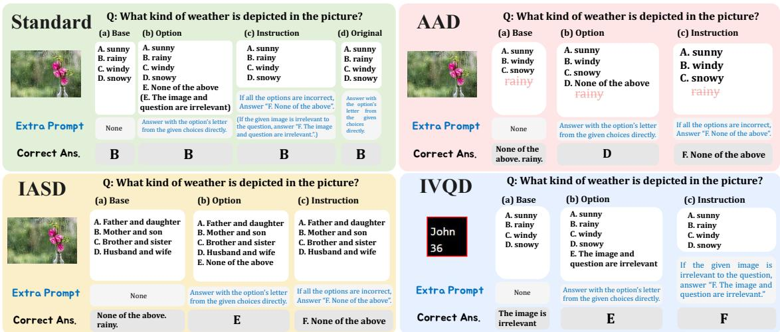

### Image 5: d2a2f27f77ad892dc62b9dd4b1051a68417f93b3f9723fd151b0f87e7f717d13.jpg (size: (780, 392))

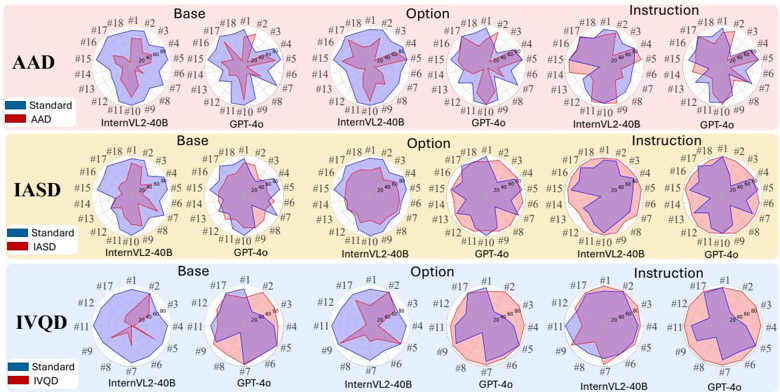

In [18]:
# ---- Show images extracted by MinerU (excluding tables) ----
from IPython.display import Image as IPImage
import io
from PIL import Image as PILImage
import json

# MinerU dumps every visual crop (figures, tables, charts) into images/.
# Use the content list to keep only true images and skip table crops.
image_paths = []
if content_list_path.exists():
    content_list = json.loads(content_list_path.read_text(encoding="utf-8"))
    image_paths = [
        parse_dir / item["img_path"]
        for item in content_list
        if item.get("type") == "image" and item.get("img_path")
    ]
    # Filter to files that actually exist and have image extensions
    image_paths = [
        p for p in image_paths
        if p.exists() and p.suffix.lower() in (".png", ".jpg", ".jpeg", ".gif", ".webp")
    ]

if image_paths:
    print(f"Number of true images found by MinerU: {len(image_paths)}\n")

    for idx, img_path in enumerate(image_paths[:5], start=1):
        img = PILImage.open(img_path).convert("RGB")
        # Resize for notebook display while keeping aspect ratio
        max_width = 780
        if img.width > max_width:
            ratio = max_width / img.width
            img = img.resize((max_width, int(img.height * ratio)))
        buf = io.BytesIO()
        img.save(buf, format="PNG")
        display(Markdown(f"### Image {idx}: {img_path.name} (size: {img.size})"))
        display(IPImage(data=buf.getvalue()))
else:
    print(f"No true images found in {images_dir}")


## VLM to Query Image Info

* `MLX-VLM` — Apple's own ML framework, built specifically for M-series chips, much faster than transformers + PyTorch's incomplete MPS-ops.

In [20]:
# ---- Load model ----
from mlx_vlm import load, generate
from mlx_vlm.prompt_utils import apply_chat_template
from mlx_vlm.utils import load_config

model_path = "mlx-community/Qwen2-VL-7B-Instruct-8bit"  # MLX-quantized, runs great on M-series
model, processor = load(model_path)
config = load_config(model_path)

# ---- Query function ----
def query_image(image_path, question):
    formatted_prompt = apply_chat_template(
        processor, config, question, num_images=1
    )
    output = generate(
        model, processor, formatted_prompt, [image_path],
        max_tokens=256, temperature=0.0, verbose=False
    )
    return output

# ---- Save the images extracted by MinerU above ----
from pathlib import Path
from PIL import Image as PILImage

image_dir = Path("extracted_images_mineru")
image_dir.mkdir(parents=True, exist_ok=True)

# `image_paths` comes from the MinerU image extraction cell above
saved_paths = []
for idx, img_path in enumerate(image_paths, start=1):
    img = PILImage.open(img_path).convert("RGB")
    save_path = image_dir / f"picture_{idx:03d}.png"
    img.save(save_path, format="PNG")
    saved_paths.append(save_path)

print(f"Saved {len(saved_paths)} images to {image_dir}")


Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 218833.25it/s]


Saved 19 images to extracted_images_mineru


### Without Image Preprocessing

In [21]:
# ---- Run VLM over the extracted images ----
question = "Describe what this image shows in detail. If it's a chart or table, extract the key data points."

def wrap_text(text, max_words_per_row=20):
    text = str(text)
    words = text.split()
    lines = []
    for i in range(0, len(words), max_words_per_row):
        lines.append(" ".join(words[i:i + max_words_per_row]))
    return "\n".join(lines)

results = {}
for path in sorted(saved_paths)[:5]:
    fname = path.name
    answer = query_image(str(path), question)
    results[fname] = answer
    print(f"\n=== {fname} ===\n{wrap_text(answer)}")


mx.metal.device_info is deprecated and will be removed in a future version. Use mx.device_info instead.



=== picture_001.png ===
GenerationResult(text='The image is a combination of a photograph and a radar chart. The photograph shows a car driving on a
road with a mountainous landscape in the background. The car appears to be silver in color.\n\nThe radar chart is titled
"What color is the car?" and has multiple categories on the x-axis, including "Image Style," "OCR," "Image Scene," "Image Emotion,"
"Image Topic," "Future Prediction," "Structured Image-text Understanding," "Physical Property Reasoning," "Function Reasoning," "Identity Reasoning," "Attribute Reasoning," "Attribute Comparison," "Action Recognition,"
"Object Location," "Nature Comparison," "Social Relation," and "Physical Property Reasoning." The y-axis ranges from 0 to 100.\n\nThe chart has two
sections labeled "AAD" and "Standard." The AAD section has a value of 20, while the Standard section has a value
of 80.\n\nThere is also a speech bubble with the text "I choose C." and another speech bubble with the text
"None of 

### Why by default, MinerU extracted images got better VLM output than Docling extracted images

* Docling optimizes for
  * Producing a readable Markdown/HTML document where images are embedded at a reasonable file size and layout.
  * Its images_scale and internal DPI defaults are chosen so the exported document looks good to a human reader and doesn’t become huge, not mathematically optimal for a vision model.

* Why MinerU images gave better VLM output
  * VLMs like Qwen2-VL process images through a vision encoder that splits the image into patches (28×28 pixels for Qwen2-VL).
  * Higher-resolution images provide more patches, which means more visual detail reaches the language model.
  * For academic PDF figures — especially charts with small labels, multi-panel figures, or tables rendered as images — MinerU’s full-resolution crops preserve text and fine structure that Docling’s downscaled versions may blur or lose.
  * MinerU also crops more tightly around individual visual regions, while Docling merges nearby regions into one picture. A MinerU crop of a single chart is often cleaner for the VLM than a Docling picture that merges the chart with surrounding text or captions.